In [1]:
import pandas as pd 
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,confusion_matrix,accuracy_score, precision_score, recall_score, f1_score,fbeta_score, roc_curve, roc_auc_score, precision_recall_curve,auc, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDRegressor, SGDClassifier, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.preprocessing import TargetEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from category_encoders import LeaveOneOutEncoder
from sklearn.ensemble import RandomForestRegressor
from scipy import stats ##
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.inspection import permutation_importance
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

In [2]:
df2 = pd.read_csv('C:\\Users\\User\\Documents\\ДЗ\\covid_19_clean_complete.csv',index_col=4,parse_dates=True) 
df2


,Province/State,Country/Region,Lat,Long,Confirmed,Deaths,Recovered,Active,WHO Region
Date,,,,,,,,,
2020-01-22,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,Eastern Mediterranean
2020-01-22,NaN,Albania,41.153300,20.168300,0,0,0,0,Europe
2020-01-22,NaN,Algeria,28.033900,1.659600,0,0,0,0,Africa
2020-01-22,NaN,Andorra,42.506300,1.521800,0,0,0,0,Europe
2020-01-22,NaN,Angola,-11.202700,17.873900,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...
2020-07-27,NaN,Sao Tome and Principe,0.186400,6.613100,865,14,734,117,Africa
2020-07-27,NaN,Yemen,15.552727,48.516388,1691,483,833,375,Eastern Mediterranean
2020-07-27,NaN,Comoros,-11.645500,43.333300,354,7,328,19,Africa


In [3]:
df2.isna().sum()

Province/State    34404
Country/Region        0
Lat                   0
Long                  0
Confirmed             0
Deaths                0
Recovered             0
Active                0
WHO Region            0
dtype: int64

In [4]:
group=df2.groupby('Country/Region')['Confirmed'].sum()
df_sorted = group.sort_values( ascending=False)
df_sorted
## Возмем для обработки США

Country/Region
US                       224345948
Brazil                    89524967
Russia                    45408411
India                     40883464
Spain                     27404045
                           ...    
Saint Kitts and Nevis         1772
Greenland                     1507
Holy See                      1356
Papua New Guinea              1185
Western Sahara                 901
Name: Confirmed, Length: 187, dtype: int64

In [5]:

df2

,Province/State,Country/Region,Lat,Long,Confirmed,Deaths,Recovered,Active,WHO Region
Date,,,,,,,,,
2020-01-22,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,Eastern Mediterranean
2020-01-22,NaN,Albania,41.153300,20.168300,0,0,0,0,Europe
2020-01-22,NaN,Algeria,28.033900,1.659600,0,0,0,0,Africa
2020-01-22,NaN,Andorra,42.506300,1.521800,0,0,0,0,Europe
2020-01-22,NaN,Angola,-11.202700,17.873900,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...
2020-07-27,NaN,Sao Tome and Principe,0.186400,6.613100,865,14,734,117,Africa
2020-07-27,NaN,Yemen,15.552727,48.516388,1691,483,833,375,Eastern Mediterranean
2020-07-27,NaN,Comoros,-11.645500,43.333300,354,7,328,19,Africa


In [6]:
df2 = df2[df2['Country/Region'] == 'US']
df2

,Province/State,Country/Region,Lat,Long,Confirmed,Deaths,Recovered,Active,WHO Region
Date,,,,,,,,,
2020-01-22,NaN,US,40.0,-100.0,1,0,0,1,Americas
2020-01-23,NaN,US,40.0,-100.0,1,0,0,1,Americas
2020-01-24,NaN,US,40.0,-100.0,2,0,0,2,Americas
2020-01-25,NaN,US,40.0,-100.0,2,0,0,2,Americas
2020-01-26,NaN,US,40.0,-100.0,5,0,0,5,Americas
...,...,...,...,...,...,...,...,...,...
2020-07-23,NaN,US,40.0,-100.0,4038816,144430,1233269,2661117,Americas
2020-07-24,NaN,US,40.0,-100.0,4112531,145560,1261624,2705347,Americas
2020-07-25,NaN,US,40.0,-100.0,4178970,146465,1279414,2753091,Americas


In [7]:
df=df2[['Confirmed']]

In [8]:
df

,Confirmed
Date,
2020-01-22,1
2020-01-23,1
2020-01-24,2
2020-01-25,2
2020-01-26,5
...,...
2020-07-23,4038816
2020-07-24,4112531
2020-07-25,4178970


In [9]:
print(df.index.is_monotonic_increasing)

True


<Axes: xlabel='Date'>

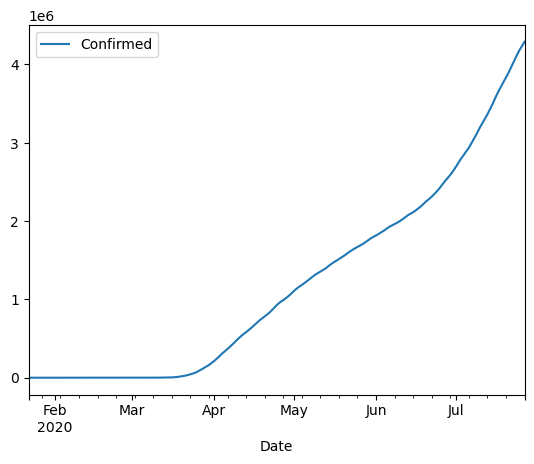

In [10]:
df.plot()

In [11]:
## Проверка на стационарность 
from statsmodels.tsa.stattools import kpss
# Проведение теста KPSS
stat, p_value, lags, crit_values = kpss(df, regression='c')

# Вывод результатов
print(f"KPSS Statistic: {stat}")
print(f"P-value: {p_value}")
print(f"Critical Values: {crit_values}")
print(f"Lags used: {lags}")


KPSS Statistic: 1.8495364539611847
P-value: 0.01
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Lags used: 9


C:\Users\User\AppData\Local\Temp\ipykernel_23932\3988120165.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p_value, lags, crit_values = kpss(df, regression='c')


<Axes: xlabel='Date'>

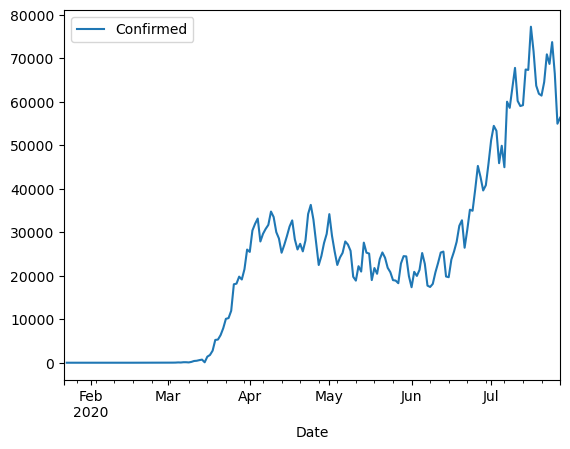

In [12]:
df3=df.diff()
df3.plot()

<Axes: xlabel='Date'>

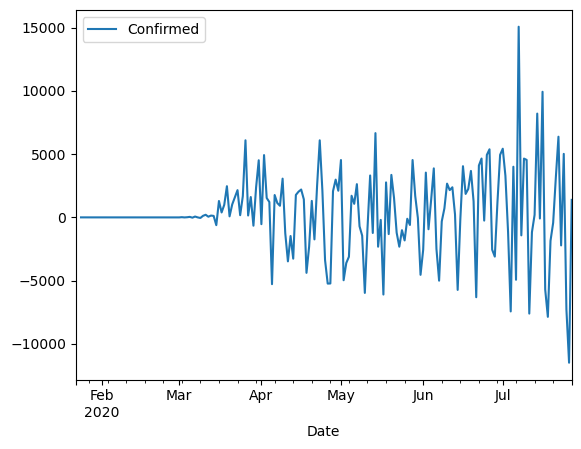

In [13]:
df4=df3.diff()
df4.plot()

In [14]:
df4.isna().sum()


Confirmed    2
dtype: int64

In [15]:
df4=df4.dropna()


In [16]:
## Проверка на стационарность 
from statsmodels.tsa.stattools import kpss
# Проведение теста KPSS
stat, p_value, lags, crit_values = kpss(df4, regression='c')

# Вывод результатов
print(f"KPSS Statistic: {stat}")
print(f"P-value: {p_value}")
print(f"Critical Values: {crit_values}")
print(f"Lags used: {lags}")

KPSS Statistic: 0.08378009888577602
P-value: 0.1
Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Lags used: 15


C:\Users\User\AppData\Local\Temp\ipykernel_23932\633117221.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p_value, lags, crit_values = kpss(df4, regression='c')


In [17]:
!pip install pmdarima
from pmdarima import auto_arima

Text(0.5, 1.0, 'Вторая производнпая')

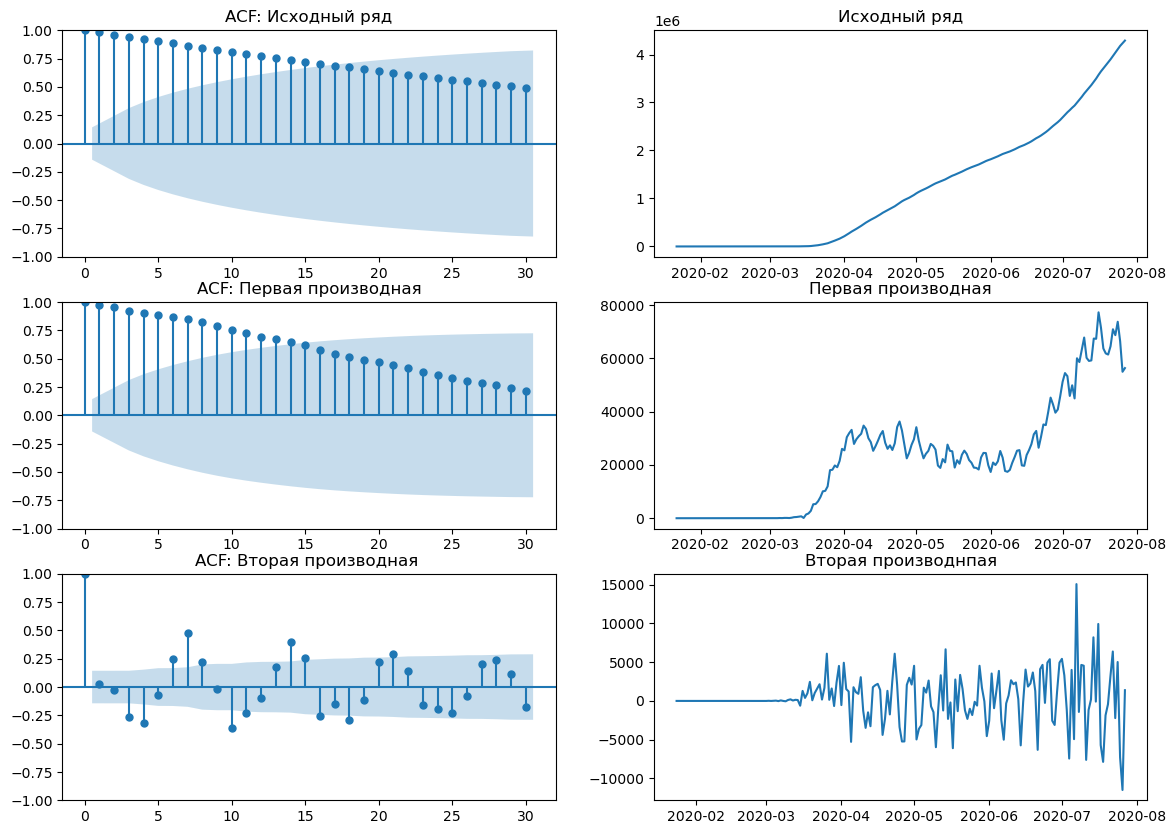

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# 1. Исходный ряд (кумулятивные случаи)
plot_acf(df['Confirmed'].dropna(), ax=axes[0,0], lags=30, title='ACF: Исходный ряд')
axes[0,1].plot(df['Confirmed'])  # для наглядности
axes[0,1].set_title('Исходный ряд')

# 2. Первая разность (прирост)
df3=df3.fillna(0)
plot_acf(df3, ax=axes[1,0], lags=30, title='ACF: Первая производная')
axes[1,1].plot(df3)
axes[1,1].set_title('Первая производная')

# 2. Вторая разность (прирост)
plot_acf(df4, ax=axes[2,0], lags=30, title='ACF: Вторая производная ')
axes[2,1].plot(df4)
axes[2,1].set_title('Вторая производнпая')

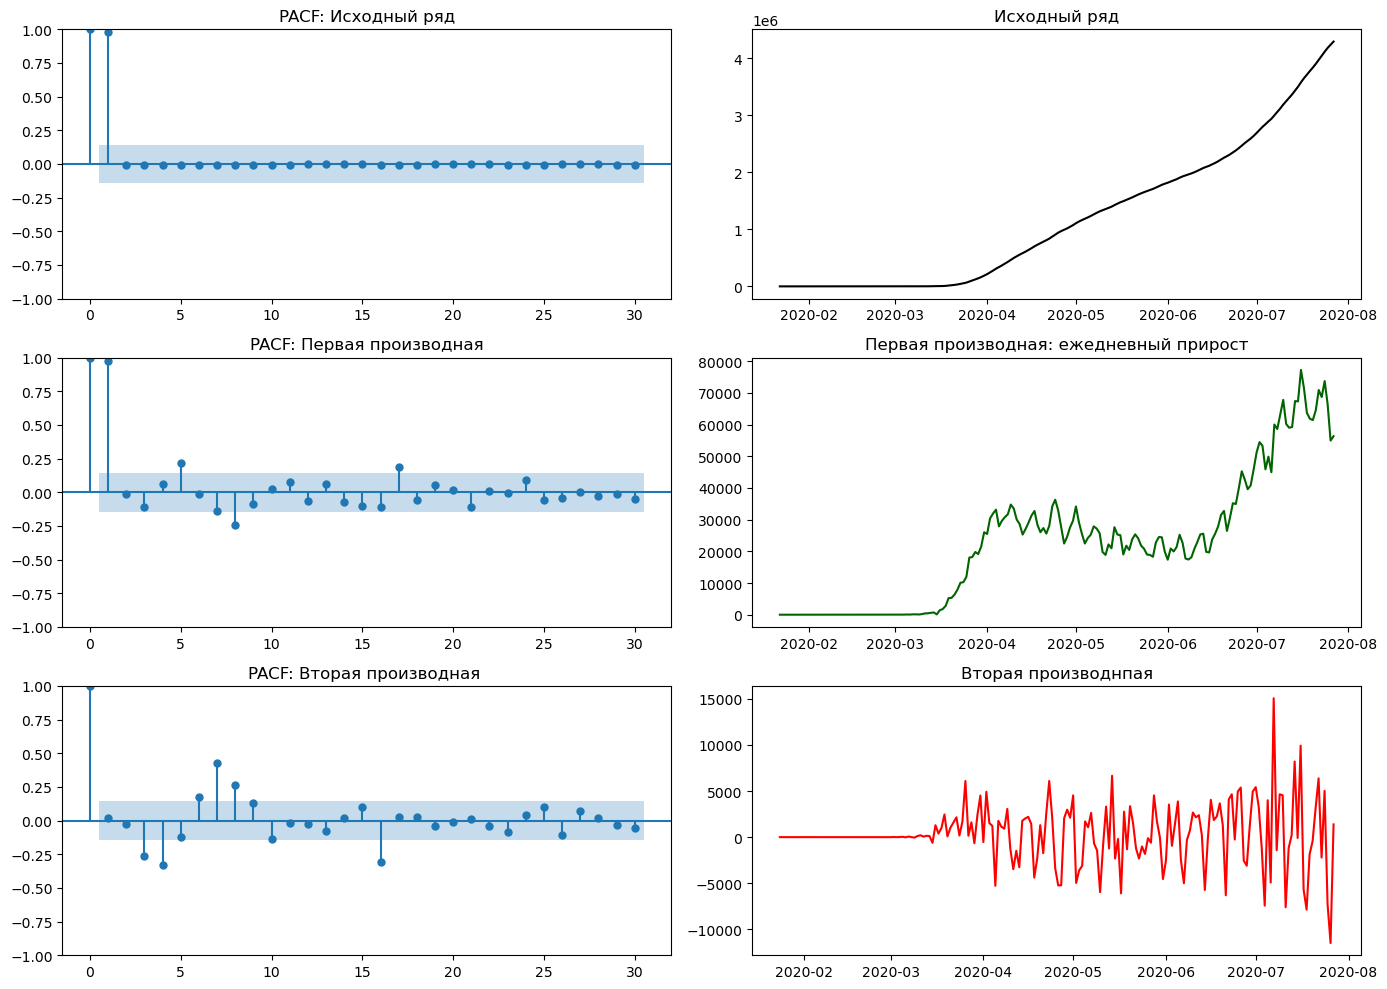

In [19]:
# Строим PACF
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

# --- Исходный ряд ---
plot_pacf(df['Confirmed'].dropna(), ax=axes[0,0], lags=30, method='ywm', title='PACF: Исходный ряд')
axes[0,1].plot(df['Confirmed'].dropna(), color='black')
axes[0,1].set_title('Исходный ряд')

# --- Первая разность ---
plot_pacf(df3, ax=axes[1,0], lags=30, method='ywm', title='PACF: Первая производная')
axes[1,1].plot(df3, color='darkgreen')
axes[1,1].set_title('Первая производная: ежедневный прирост')


# 2. Вторая разность (прирост)
plot_pacf(df4, ax=axes[2,0], lags=30,method='ywm', title='PACF: Вторая производная ')
axes[2,1].plot(df4, color='red')
axes[2,1].set_title('Вторая производнпая')
plt.tight_layout()
plt.show()

Подбираем параметры ARIMA
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=3477.452, Time=0.14 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=3540.385, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=3542.291, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=3542.329, Time=0.01 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=3540.001, Time=0.01 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=3546.789, Time=0.04 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=3541.585, Time=0.07 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=3464.002, Time=0.07 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=3521.119, Time=0.05 sec
 ARIMA(3,2,3)(0,0,0)[0] intercept   : AIC=3458.153, Time=0.29 sec
 ARIMA(2,2,3)(0,0,0)[0] intercept   : AIC=3458.746, Time=0.24 sec
 ARIMA(3,2,3)(0,0,0)[0]             : AIC=3463.163, Time=0.26 sec

Best model:  ARIMA(3,2,3)(0,0,0)[0] intercept
Total fit time: 1.209 seconds

»> Лучшая модель: ARIMA(3, 2, 3)
                            

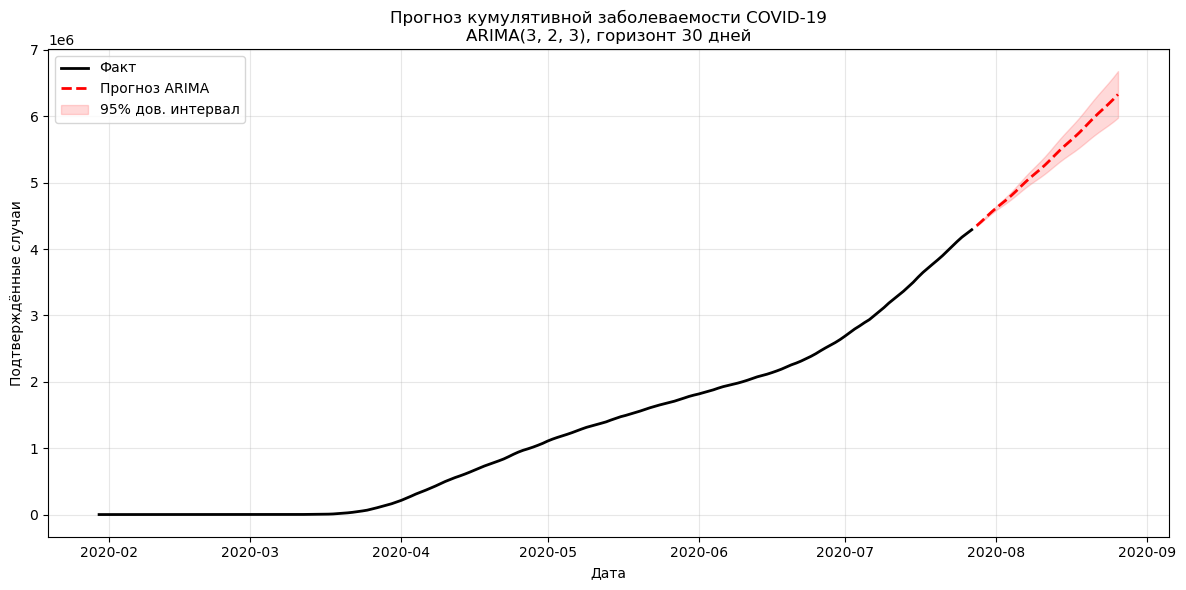

In [20]:
## 1 . Построение модели AUTOARIMA
confirmed = df['Confirmed']
print("Подбираем параметры ARIMA")
model = auto_arima(
    confirmed,
    seasonal=False, # для COVIDа ранней  стадии — сезонности почти нет
    max_p=3, max_q=3, max_d=2,
    trace=True, #режим подробного вывода процесса подбора модели
    suppress_warnings=True, #отключение предупреждений (warnings) от библиотек нижнего уровня
    error_action='ignore', # если какая‑то комбинация (p,d,q) вызывает ошибку (например, не сходится оценка параметров), алгоритм просто пропускает её и переходит к следующей
    stepwise=True  ## Оптимальный перебор параметров
)

print(f"\n»> Лучшая модель: ARIMA{model.order}")
print(model.summary())

# 2. ПРОГНОЗ НА 30 ДНЕЙ
n_days = 30
forecast, conf_int = model.predict(n_periods=n_days, return_conf_int=True)  ##возвращать доверительные интервалы вместе с прогнозом.

last_date = confirmed.index[-1]
future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=n_days,
    freq='D' ## Частота между соседними шагами
)

forecast_df = pd.DataFrame({
    'Прогноз': forecast,
    'Нижняя граница': conf_int[:, 0],
    'Верхняя граница': conf_int[:, 1]
}, index=future_dates)


# 3. ТАБЛИЦА

print("\nПрогноз на 30 дней вперёд:")
print(forecast_df.round(0).astype(int).to_string())


# 4. ГРАФИК

plt.figure(figsize=(12, 6))

# Последние 180 дней истории для наглядности
hist = confirmed.iloc[-180:]
plt.plot(hist.index, hist, color='black', linewidth=2, label='Факт')

# Прогноз
plt.plot(forecast_df.index, forecast_df['Прогноз'],
         color='red', linestyle='--', linewidth=2, label='Прогноз ARIMA')

# 95% доверительный интервал
plt.fill_between(
    forecast_df.index,
    forecast_df['Нижняя граница'],
    forecast_df['Верхняя граница'],
    color='red', alpha=0.15, label='95% дов. интервал'
)

plt.title(f'Прогноз кумулятивной заболеваемости COVID-19\nARIMA{model.order}, горизонт {n_days} дней')
plt.xlabel('Дата')
plt.ylabel('Подтверждённые случаи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
## Уровень 2

Performing stepwise search to minimize aic


C:\Users\User\AppData\Local\Temp\ipykernel_23932\3175422473.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['New'] = df3 ## Добавляем значения производной к исходному датафрейму ->прирост заболевших каждый день


 ARIMA(2,2,2)(0,0,0)[0] intercept   : AIC=2830.849, Time=0.15 sec
 ARIMA(0,2,0)(0,0,0)[0] intercept   : AIC=2882.128, Time=0.01 sec
 ARIMA(1,2,0)(0,0,0)[0] intercept   : AIC=2881.631, Time=0.01 sec
 ARIMA(0,2,1)(0,0,0)[0] intercept   : AIC=2881.256, Time=0.01 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=2882.068, Time=0.00 sec
 ARIMA(1,2,2)(0,0,0)[0] intercept   : AIC=2884.630, Time=0.07 sec
 ARIMA(2,2,1)(0,0,0)[0] intercept   : AIC=2878.775, Time=0.04 sec
 ARIMA(3,2,2)(0,0,0)[0] intercept   : AIC=2827.911, Time=0.19 sec
 ARIMA(3,2,1)(0,0,0)[0] intercept   : AIC=2872.162, Time=0.05 sec
 ARIMA(3,2,3)(0,0,0)[0] intercept   : AIC=2827.393, Time=0.18 sec
 ARIMA(2,2,3)(0,0,0)[0] intercept   : AIC=2828.332, Time=0.14 sec
 ARIMA(3,2,3)(0,0,0)[0]             : AIC=2829.595, Time=0.16 sec

Best model:  ARIMA(3,2,3)(0,0,0)[0] intercept
Total fit time: 1.023 seconds

Лучшая модель: ARIMA(3, 2, 3)

СРАВНЕНИЕ НА ТЕСТЕ (последние 30 дней)
           Модель       MAE      RMSE  MAPE, %
            A

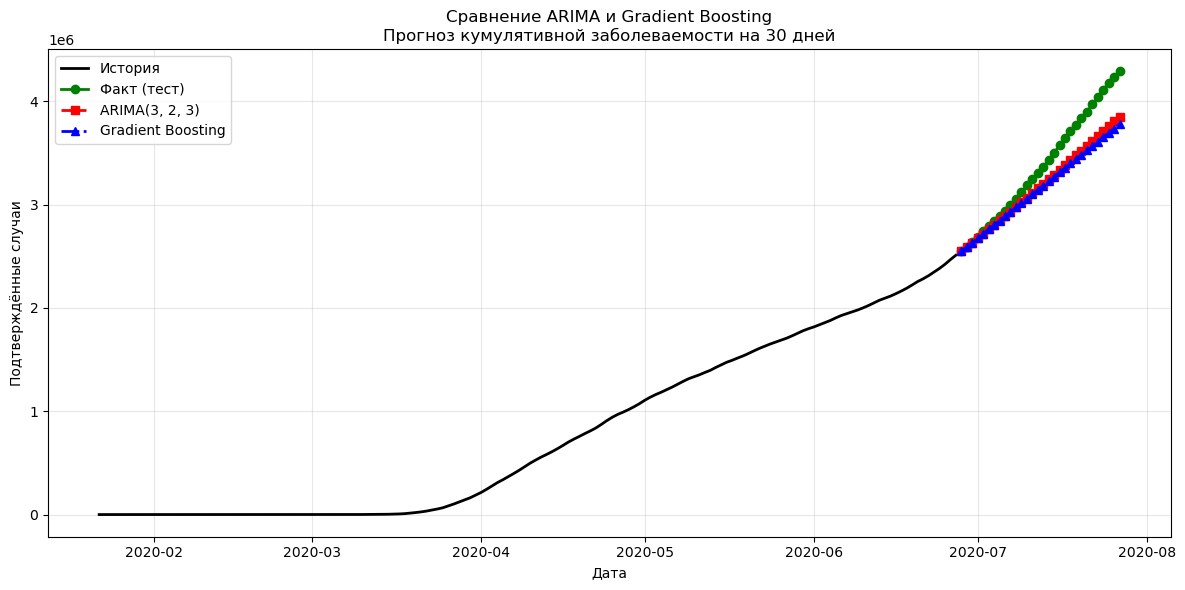

In [22]:
# 1. РАЗБИЕНИЕ: последние 30 дней — тест
# ============================================================
df['New'] = df3 ## Добавляем значения производной к исходному датафрейму ->прирост заболевших каждый день
HORIZON = 30

train = df.iloc[:-HORIZON] 
test  = df.iloc[-HORIZON:] 

actual = test['Confirmed'].values ## Ревльные значения на тестовом промежутке
last_confirmed = train['Confirmed'].iloc[-1] ## Последнее значение перед прогнозом
last_date = train.index[-1]  ## Последняя дата из обучающей части
#2. Еще раз обучает ARIMY - теперь не на всех а, на тестовых данных
arima_model = auto_arima(
    train['Confirmed'],
    seasonal=False,
    max_p=3, max_q=3, max_d=2,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)
print(f"\nЛучшая модель: ARIMA{arima_model.order}")
pred_arima = arima_model.predict(n_periods=HORIZON)
# 3. GRADIENT BOOSTING (на приростах)
def make_features(series):
    d = pd.DataFrame({'New': series}) 
    for lag in [1, 2, 3, 7, 14]:## ЛАги -значения прироста 1,2,3,7,14 дней назад
        d[f'lag_{lag}'] = d['New'].shift(lag) ## сдвигает значения столбца вниз на lag строк
    d['roll_mean_3'] = d['New'].shift(1).rolling(3).mean() ## Среднее за 3 дня 
    d['roll_mean_7'] = d['New'].shift(1).rolling(7).mean() ## Среднее за 7 дней 
    d['roll_std_7']  = d['New'].shift(1).rolling(7).std()  ## Стандартное отклонение за 7 дней 
    d['dayofweek'] = series.index.dayofweek                ## День недели
    d['days_from_start'] = (series.index - series.index[0]).days  ## Сколко дней прошло от начала ряда
    return d.dropna()

feat_train = make_features(train['New'])
X_train = feat_train.drop(columns='New')
y_train = feat_train['New']  ## Целевая переменная- прирост 

# 4.Обучение
gb = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)
gb.fit(X_train, y_train)

# .Рекурсивный прогноз приростов - т.к гб прогнозирует только один шаг то сначала делается прогноз за 1 день -> добавляется к истории -> прогнозируетмя день 2 с учетом уже предсказанного дня 1
history = train['New'].tolist()
pred_new = []

for i in range(1, HORIZON + 1):
    next_date = last_date + pd.Timedelta(days=i)
    h = np.array(history)
## Формирование признаков для будующего дня
    row = {
        'lag_1':  history[-1],
        'lag_2':  history[-2]  if len(history) >= 2  else history[-1],
        'lag_3':  history[-3]  if len(history) >= 3  else history[-1],
        'lag_7':  history[-7]  if len(history) >= 7  else np.mean(h),
        'lag_14': history[-14] if len(history) >= 14 else np.mean(h),
        'roll_mean_3': np.mean(h[-3:]) if len(h) >= 3 else np.mean(h),
        'roll_mean_7': np.mean(h[-7:]) if len(h) >= 7 else np.mean(h),
        'roll_std_7':  np.std(h[-7:])  if len(h) >= 7 else 0.0,
        'dayofweek': next_date.dayofweek,
        'days_from_start': (next_date - train.index[0]).days,
    }

    X_next = pd.DataFrame([row])[X_train.columns]
    p = max(0, gb.predict(X_next)[0]) ## прогноз прироста и накопление  
    pred_new.append(p)
    history.append(p)

pred_new = np.array(pred_new)
pred_boost = last_confirmed + np.cumsum(pred_new) ## перевод прироста в кумулятивный прогноз

## 5. МЕТРИКИ

# ============================================================
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100

metrics = pd.DataFrame({
    'Модель': ['ARIMA', 'Gradient Boosting'],
    'MAE': [
        mean_absolute_error(actual, pred_arima),
        mean_absolute_error(actual, pred_boost)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(actual, pred_arima)),
        np.sqrt(mean_squared_error(actual, pred_boost))
    ],
    'MAPE, %': [
        mape(actual, pred_arima),
        mape(actual, pred_boost)
    ]
}).round(2)

print("\n" + "="*50)
print("СРАВНЕНИЕ НА ТЕСТЕ (последние 30 дней)")
print("="*50)
print(metrics.to_string(index=False))

# ============================================================
# 6. ГРАФИК
# ============================================================
plt.figure(figsize=(12, 6))

# История (последние 200 дней до теста)
hist = train['Confirmed'].iloc[-200:]
plt.plot(hist.index, hist, color='black', linewidth=2, label='Факт')

# Тест
plt.plot(test.index, actual, color='green', linewidth=2, marker='o', label='Факт (тест)')

# Прогнозы
plt.plot(test.index, pred_arima, color='red', linestyle='--', linewidth=2, marker='s', label=f'ARIMA{arima_model.order}')
plt.plot(test.index, pred_boost, color='blue', linestyle='-.', linewidth=2, marker='^', label='Gradient Boosting')

plt.title('Сравнение ARIMA и Gradient Boosting\nПрогноз кумулятивной заболеваемости на 30 дней')
plt.xlabel('Дата')
plt.ylabel('Подтверждённые случаи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
##Уровень 3

In [24]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [25]:
from prophet import Prophet

In [26]:
print("\nОбучение Prophet...")

# Prophet требует колонки ds и y
prophet_df = train.reset_index()[['Date', 'Confirmed']].rename(
    columns={'Date': 'ds', 'Confirmed': 'y'}
)

prophet_model = Prophet(
    daily_seasonality=False,## СУТОЧНАЯ СЕЗОННОСТЬ
    weekly_seasonality=True,## недельная СЕЗОННОСТЬ
    yearly_seasonality=False,## годовая СЕЗОННОСТЬ
    changepoint_prior_scale=0.05,##чувствительность модели к резким изменениям тренда
    interval_width=0.95 ## Ширина доверительного интревала
)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=HORIZON, include_history=False)## таблица с 30 днями (прогноз) начина с last_date

forecast_prophet = prophet_model.predict(future)
pred_prophet = forecast_prophet['yhat'].values


Обучение Prophet...


00:11:47 - cmdstanpy - INFO - Chain [1] start processing
00:11:48 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
## Обновляем словаь с метриками,добавляя Prophet
metrics = pd.DataFrame({
    'Модель': ['ARIMA', 'Gradient Boosting', 'Prophet'],
    'MAE': [
        mean_absolute_error(actual, pred_arima),
        mean_absolute_error(actual, pred_boost),
        mean_absolute_error(actual, pred_prophet)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(actual, pred_arima)),
        np.sqrt(mean_squared_error(actual, pred_boost)),
        np.sqrt(mean_squared_error(actual, pred_prophet))
    ],
    'MAPE, %': [
        mape(actual, pred_arima),
        mape(actual, pred_boost),
        mape(actual, pred_prophet)
    ]
}).round(2)
print("\n" + "="*50)
print("СРАВНЕНИЕ НА ТЕСТЕ (последние 30 дней)")
print("="*50)
print(metrics.to_string(index=False))


СРАВНЕНИЕ НА ТЕСТЕ (последние 30 дней)
           Модель       MAE      RMSE  MAPE, %
            ARIMA 185214.33 236379.10     4.94
Gradient Boosting 207729.35 268146.77     5.52
          Prophet 578184.48 666469.95    16.00


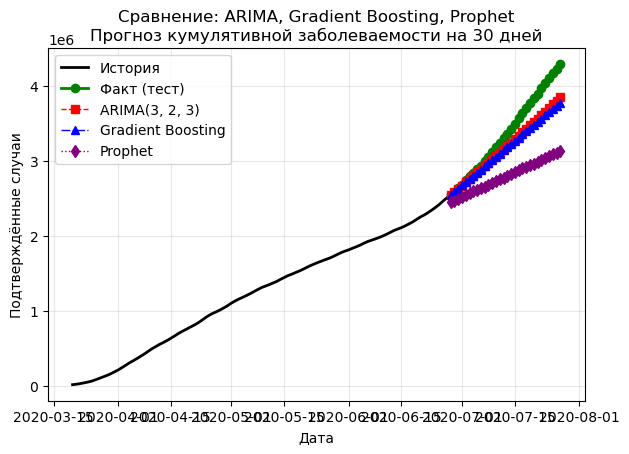

In [28]:
hist = train['Confirmed'].iloc[-100:]
plt.plot(hist.index, hist, color='black', linewidth=2, label='Факт')

# Тест
plt.plot(test.index, actual, color='green', linewidth=2, marker='o', label='Факт (тест)')
# Модели
plt.plot(test.index, pred_arima,  color='red',    linestyle='--',  linewidth=1, marker='s', label=f'ARIMA{arima_model.order}')
plt.plot(test.index, pred_boost,  color='blue',   linestyle='-.',  linewidth=1, marker='^', label='Gradient Boosting')
plt.plot(test.index, pred_prophet, color='purple', linestyle=':',   linewidth=1, marker='d', label='Prophet')

plt.title('Сравнение: ARIMA, Gradient Boosting, Prophet\nПрогноз кумулятивной заболеваемости на 30 дней')
plt.xlabel('Дата')
plt.ylabel('Подтверждённые случаи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [29]:
## ""Сравнить с бейзалайн -решением" -  непонятно с каким именно. Поэтому взял самый простой - константный

In [30]:

pred_const = np.full(HORIZON, train['Confirmed'].mean())

In [31]:
pred_const

array([779800.8164557, 779800.8164557, 779800.8164557, 779800.8164557,
       779800.8164557, 779800.8164557, 779800.8164557, 779800.8164557,
       779800.8164557, 779800.8164557, 779800.8164557, 779800.8164557,
       779800.8164557, 779800.8164557, 779800.8164557, 779800.8164557,
       779800.8164557, 779800.8164557, 779800.8164557, 779800.8164557,
       779800.8164557, 779800.8164557, 779800.8164557, 779800.8164557,
       779800.8164557, 779800.8164557, 779800.8164557, 779800.8164557,
       779800.8164557, 779800.8164557])

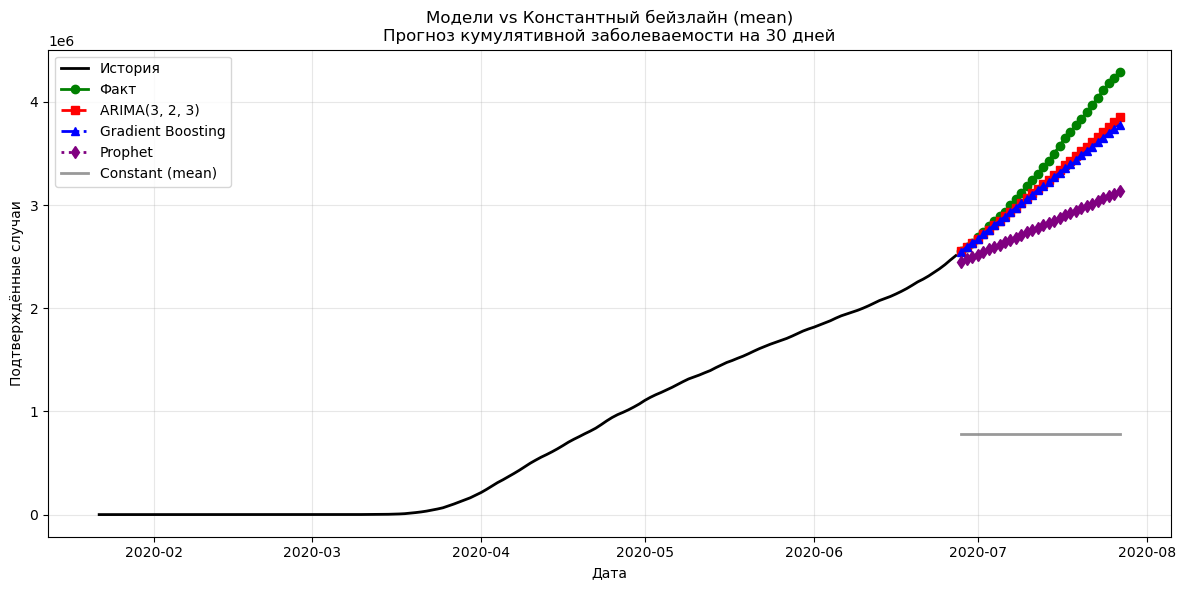

In [32]:
plt.figure(figsize=(12, 6))

hist = train['Confirmed'].iloc[-200:]
plt.plot(hist.index, hist, color='black', linewidth=2, label='Факт')
plt.plot(test.index, actual, color='green', linewidth=2, marker='o', label='Факт')

# Модели
plt.plot(test.index, pred_arima,  color='red',    linestyle='--',  linewidth=2, marker='s', label=f'ARIMA{arima_model.order}')
plt.plot(test.index, pred_boost,  color='blue',   linestyle='-.',  linewidth=2, marker='^', label='Gradient Boosting')
plt.plot(test.index, pred_prophet, color='purple', linestyle=':',   linewidth=2, marker='d', label='Prophet')

# Бейзлайн
plt.plot(test.index, pred_const, color='gray', linestyle='-', alpha=0.8, linewidth=2, label='Constant (mean)')

plt.title('Модели vs Константный бейзлайн (mean)\nПрогноз кумулятивной заболеваемости на 30 дней')
plt.xlabel('Дата')
plt.ylabel('Подтверждённые случаи')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
##Сравнить результат со сглаживанием и без.
## добавил данные smooth, и перевел все выше модели в фунукции

C:\Users\User\AppData\Local\Temp\ipykernel_23932\3160324767.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['New_smooth'] = train['New'].rolling(window=7, min_periods=1).mean()
C:\Users\User\AppData\Local\Temp\ipykernel_23932\3160324767.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train['Confirmed_smooth'] = train['Confirmed'].iloc[0] + train['New_smooth'].cumsum()
00:45:30 - cmdstanpy - INFO - Chain [1] start processing
00:45:30 - cmdstanpy - INFO - Chain [1] done processing
00:45:30 - cmd


СРАВНЕНИЕ: ОРИГИНАЛ vs СГЛАЖЕННЫЙ РЯД (метрики vs факт)
           Модель        MAE       RMSE  MAPE, %
  Constant (mean) 2591446.48 2646075.06    76.27
            ARIMA  185214.33  236379.10     4.94
   ARIMA (smooth)  263824.79  285823.28     7.51
         Boosting  207729.35  268146.77     5.52
Boosting (smooth)  460334.12  522556.76    12.83
          Prophet  578184.48  666469.95    16.00
 Prophet (smooth)  686047.17  766022.77    19.24


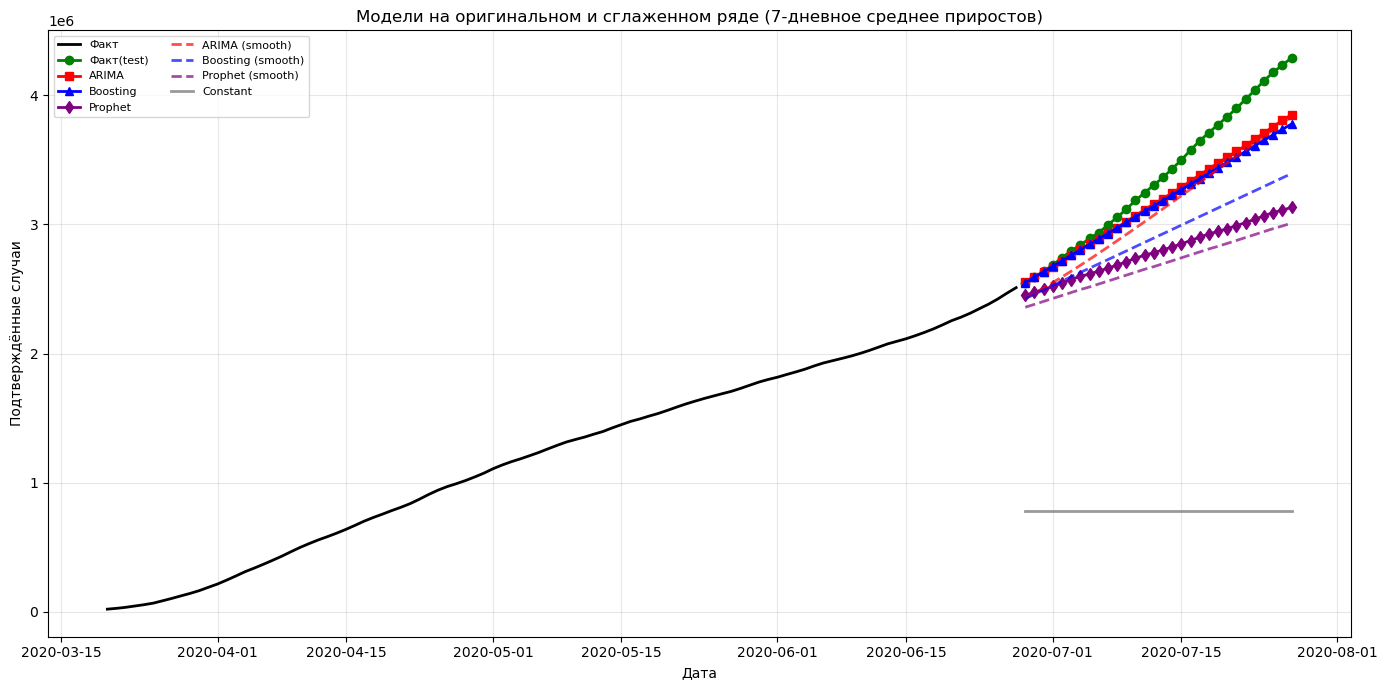

In [39]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
# Каузальное сглаживание: 7-дневное среднее приростов, затем кумулятивная сумма
train['New_smooth'] = train['New'].rolling(window=7, min_periods=1).mean()
train['Confirmed_smooth'] = train['Confirmed'].iloc[0] + train['New_smooth'].cumsum()
last_confirmed_smooth = train['Confirmed_smooth'].iloc[-1]

# ============================================================
#  ARIMA (оригинал + сглаженный)
# ============================================================
def run_arima(series):
    arima_model = auto_arima(
        series, seasonal=False, max_p=3, max_q=3, max_d=2,
        trace=False, suppress_warnings=True, stepwise=True
    )
    return arima_model.predict(n_periods=HORIZON)

pred_arima        = run_arima(train['Confirmed'])
pred_arima_smooth = run_arima(train['Confirmed_smooth'])

# ============================================================
#  GRADIENT BOOSTING (оригинал + сглаженный)
# ============================================================
def run_boosting(target_series, last_cum):
    feat = make_features(target_series)
    X_tr = feat.drop(columns='New')
    y_tr = feat['New']

    gb = GradientBoostingRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42
    )
    gb.fit(X_tr, y_tr)

    history = target_series.tolist()
    preds = []
    for i in range(1, HORIZON + 1):
        next_date = last_date + pd.Timedelta(days=i)
        h = np.array(history)
        row = {
            'lag_1':  history[-1],
            'lag_2':  history[-2]  if len(history) >= 2  else history[-1],
            'lag_3':  history[-3]  if len(history) >= 3  else history[-1],
            'lag_7':  history[-7]  if len(history) >= 7  else np.mean(h),
            'lag_14': history[-14] if len(history) >= 14 else np.mean(h),
            'roll_mean_3': np.mean(h[-3:]) if len(h) >= 3 else np.mean(h),
            'roll_mean_7': np.mean(h[-7:]) if len(h) >= 7 else np.mean(h),
            'roll_std_7':  np.std(h[-7:])  if len(h) >= 7 else 0.0,
            'dayofweek': next_date.dayofweek,
            'days_from_start': (next_date - train.index[0]).days,
        }
        X_next = pd.DataFrame([row])[X_tr.columns]
        p = max(0, gb.predict(X_next)[0])
        preds.append(p)
        history.append(p)
    return last_cum + np.cumsum(np.array(preds))

pred_boost        = run_boosting(train['New'], last_confirmed)
pred_boost_smooth = run_boosting(train['New_smooth'], last_confirmed_smooth)

# ============================================================
#  PROPHET (оригинал + сглаженный)
# ============================================================
def run_prophet(series):
    df_p = series.reset_index().rename(columns={'Date': 'ds', series.name: 'y'})
    m = Prophet(
        daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=False,
        changepoint_prior_scale=0.05, interval_width=0.95
    )
    m.fit(df_p)
    future = m.make_future_dataframe(periods=HORIZON, include_history=False)
    fcst = m.predict(future)
    return fcst['yhat'].values

pred_prophet        = run_prophet(train['Confirmed'])
pred_prophet_smooth = run_prophet(train['Confirmed_smooth'])


# ============================================================
#  КОНСТАНТНЫЙ БЕЙЗЛАЙН
# ============================================================
pred_const = np.full(HORIZON, train['Confirmed'].mean())

# ============================================================
# 9. МЕТРИКИ (все vs оригинальный факт)
# ============================================================
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100

models = {
    'Constant (mean)':      pred_const,
    'ARIMA':                pred_arima,
    'ARIMA (smooth)':       pred_arima_smooth,
    'Boosting':             pred_boost,
    'Boosting (smooth)':    pred_boost_smooth,
    'Prophet':              pred_prophet,
    'Prophet (smooth)':     pred_prophet_smooth,
}

metrics = []
for name, pred in models.items():
    metrics.append({
        'Модель': name,
        'MAE': mean_absolute_error(actual, pred),
        'RMSE': np.sqrt(mean_squared_error(actual, pred)),
        'MAPE, %': mape(actual, pred)
    })

metrics_df = pd.DataFrame(metrics).round(2)
print("\n" + "="*70)
print("СРАВНЕНИЕ: ОРИГИНАЛ vs СГЛАЖЕННЫЙ РЯД (метрики vs факт)")
print("="*70)
print(metrics_df.to_string(index=False))

# ============================================================
# 10. ГРАФИК
# ============================================================
plt.figure(figsize=(14, 7))

hist = train['Confirmed'].iloc[-100:]
plt.plot(hist.index, hist, color='black', linewidth=2, label='Факт')
plt.plot(test.index, actual, color='green', linewidth=2, marker='o', label='Факт(test)')

# Оригинал — сплошные линии
plt.plot(test.index, pred_arima,      color='red',    linewidth=2, marker='s', label='ARIMA')
plt.plot(test.index, pred_boost,      color='blue',   linewidth=2, marker='^', label='Boosting')
plt.plot(test.index, pred_prophet,     color='purple', linewidth=2, marker='d', label='Prophet')

# Сглаженный — штриховые линии
plt.plot(test.index, pred_arima_smooth,  color='red',    linestyle='--', alpha=0.7, linewidth=2, label='ARIMA (smooth)')
plt.plot(test.index, pred_boost_smooth,  color='blue',   linestyle='--', alpha=0.7, linewidth=2, label='Boosting (smooth)')
plt.plot(test.index, pred_prophet_smooth, color='purple', linestyle='--', alpha=0.7, linewidth=2, label='Prophet (smooth)')


# Бейзлайн
plt.plot(test.index, pred_const, color='gray', linestyle='-', alpha=0.8, linewidth=2, label='Constant')

plt.title('Модели на оригинальном и сглаженном ряде (7-дневное среднее приростов)')
plt.xlabel('Дата')
plt.ylabel('Подтверждённые случаи')
plt.legend(ncol=2, fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()